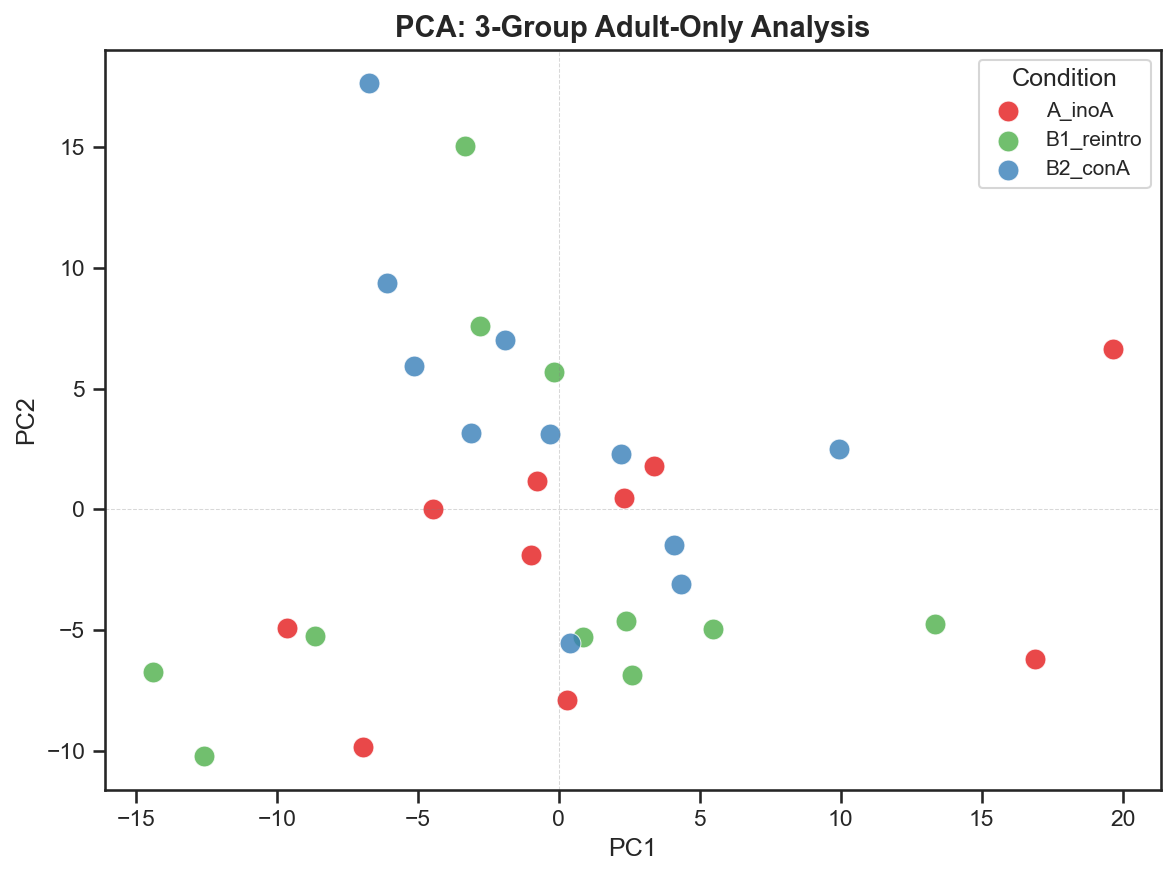

PCA plot saved: 3group_analysis_PCA.png


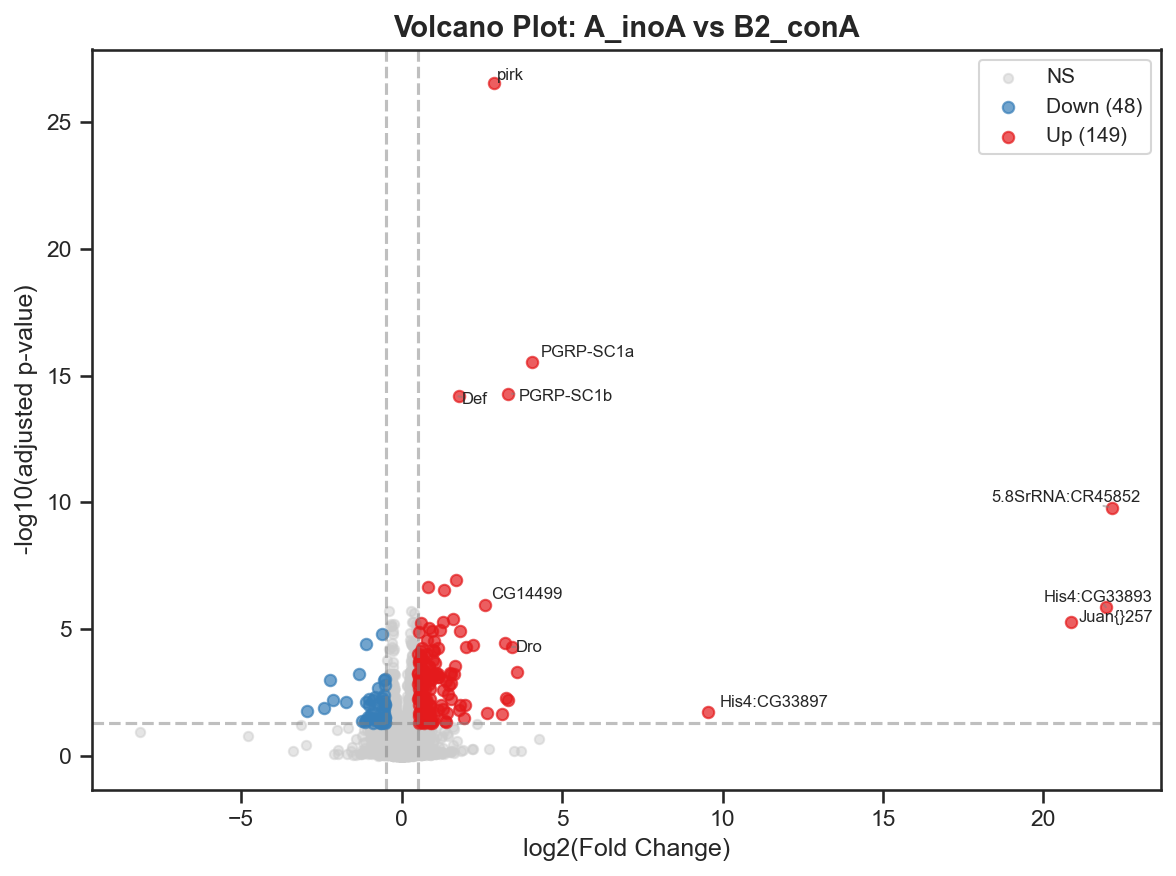

Volcano plot saved: 3group_analysis_volcano_A_inoA_vs_B2_conA.png


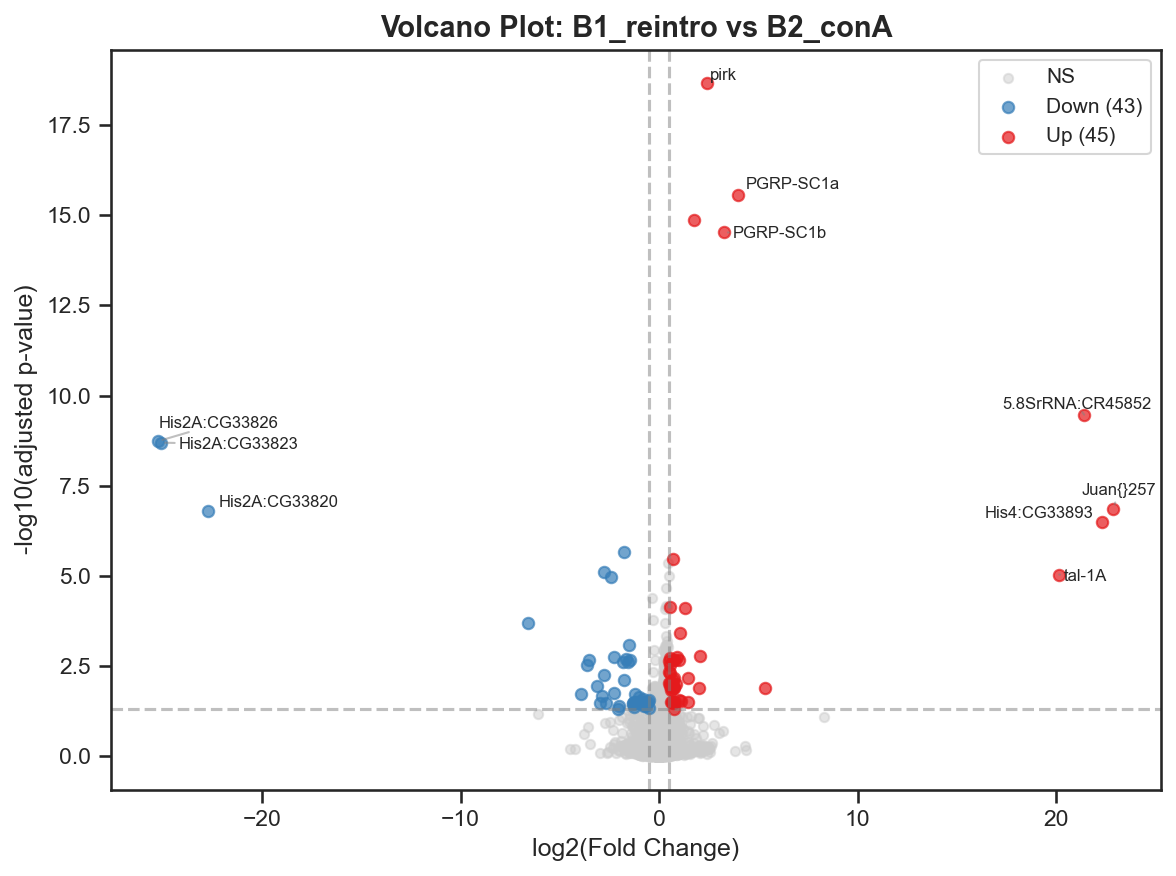

Volcano plot saved: 3group_analysis_volcano_B1_reintro_vs_B2_conA.png


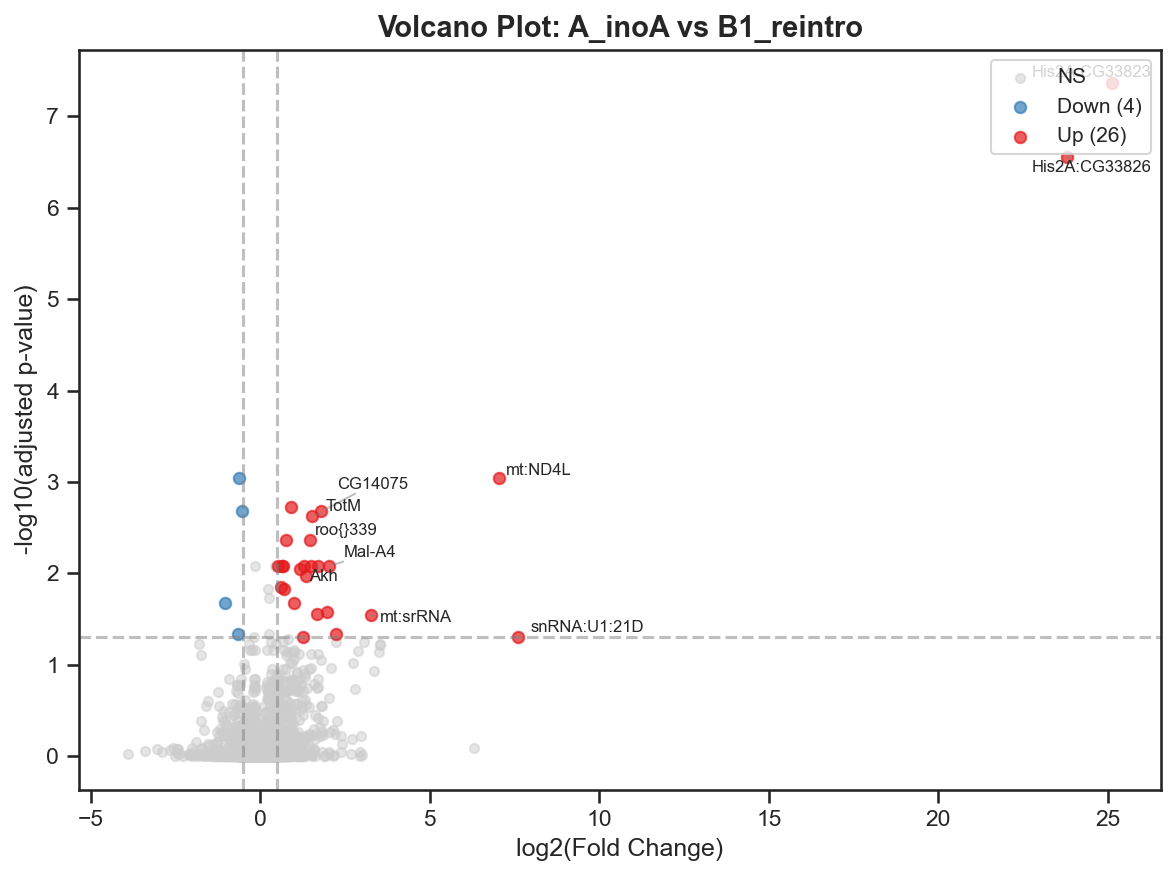

Volcano plot saved: 3group_analysis_volcano_A_inoA_vs_B1_reintro.png
Combined volcano plot saved: 3group_analysis_volcanos_combined.png/svg


FileNotFoundError: [Errno 2] No such file or directory: 'DESeq2_3group_results/RECOVERED.csv'

In [2]:
# ============================================================================
# Python Visualization Code for 3-Group DESeq2 Analysis
# ============================================================================
# 
# This script generates:
#   1. PCA plot (using VST-transformed data from DESeq2)
#   2. Volcano plots for all 3 pairwise comparisons
#   3. Gene list comparison (Venn diagram / UpSet plot)
#
# Prerequisites: Run DESeq2_3group_analysis.R first to generate input files
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn3
from adjustText import adjust_text

# Set style
sns.set_theme(style="ticks")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

# ============================================================================
# COLOR PALETTE
# ============================================================================
COLORS = {
    'A_inoA': '#E41A1C',      # Red - embryonic colonization
    'B1_reintro': '#4DAF4A',  # Green - adult recolonization
    'B2_conA': '#377EB8',     # Blue - germ-free control
    'up': '#E41A1C',          # Red for upregulated
    'down': '#377EB8',        # Blue for downregulated
    'ns': '#CCCCCC'           # Gray for non-significant
}

# ============================================================================
# 1. PCA PLOT
# ============================================================================
def plot_pca(pca_file, output_prefix):
    """
    Create PCA plot from DESeq2 VST-transformed data.

    Parameters:
        pca_file: Path to pca_data.csv from R script
        output_prefix: Prefix for output files
    """
    # Load PCA data
    pca_df = pd.read_csv(pca_file)

    # Extract variance explained from column names or calculate
    # DESeq2's plotPCA returns PC1 and PC2 columns

    # Create figure
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot each group
    for group in ['A_inoA', 'B1_reintro', 'B2_conA']:
        data = pca_df[pca_df['condition'] == group]
        ax.scatter(data['PC1'], data['PC2'], 
                   c=COLORS[group], label=group, 
                   s=100, alpha=0.8, edgecolors='white', linewidth=0.5)

    # Labels and formatting
    ax.set_xlabel('PC1', fontsize=12)
    ax.set_ylabel('PC2', fontsize=12)
    ax.set_title('PCA: 3-Group Adult-Only Analysis', fontsize=14, fontweight='bold')
    ax.legend(title='Condition', loc='best', fontsize=10)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3, linewidth=0.5)
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.3, linewidth=0.5)

    plt.tight_layout()
    plt.savefig(f'{output_prefix}_PCA.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    print(f"PCA plot saved: {output_prefix}_PCA.png")


# ============================================================================
# 2. VOLCANO PLOTS
# ============================================================================
def plot_volcano(results_file, comparison_name, output_prefix, 
                 padj_thresh=0.05, lfc_thresh=0.5, top_n_labels=10):
    """
    Create volcano plot for a DESeq2 comparison.

    Parameters:
        results_file: Path to full DESeq2 results CSV
        comparison_name: Name for the plot title (e.g., "A_inoA vs B2_conA")
        output_prefix: Prefix for output files
        padj_thresh: Adjusted p-value threshold
        lfc_thresh: Log2 fold change threshold
        top_n_labels: Number of top genes to label
    """
    # Load data
    df = pd.read_csv(results_file)
    df = df.dropna(subset=['padj', 'log2FoldChange'])

    # Calculate -log10(padj)
    df['neg_log10_padj'] = -np.log10(df['padj'])

    # Classify genes
    df['category'] = 'ns'
    df.loc[(df['padj'] <= padj_thresh) & (df['log2FoldChange'] >= lfc_thresh), 'category'] = 'up'
    df.loc[(df['padj'] <= padj_thresh) & (df['log2FoldChange'] <= -lfc_thresh), 'category'] = 'down'

    # Count DEGs
    n_up = (df['category'] == 'up').sum()
    n_down = (df['category'] == 'down').sum()

    # Create figure
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot non-significant first (background)
    ns_data = df[df['category'] == 'ns']
    ax.scatter(ns_data['log2FoldChange'], ns_data['neg_log10_padj'],
               c=COLORS['ns'], s=20, alpha=0.5, label='NS')

    # Plot significant genes
    for cat, label in [('down', f'Down ({n_down})'), ('up', f'Up ({n_up})')]:
        cat_data = df[df['category'] == cat]
        ax.scatter(cat_data['log2FoldChange'], cat_data['neg_log10_padj'],
                   c=COLORS[cat], s=30, alpha=0.7, label=label)

    # Add threshold lines
    ax.axhline(y=-np.log10(padj_thresh), color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=lfc_thresh, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=-lfc_thresh, color='gray', linestyle='--', alpha=0.5)

    # Label top genes
    sig_df = df[df['category'] != 'ns'].copy()
    sig_df['rank'] = sig_df['neg_log10_padj'] * abs(sig_df['log2FoldChange'])
    top_genes = sig_df.nlargest(top_n_labels, 'rank')

    texts = []
    for _, row in top_genes.iterrows():
        texts.append(ax.text(row['log2FoldChange'], row['neg_log10_padj'], 
                             row['gene_name'], fontsize=8))

    if texts:
        adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5))

    # Labels and formatting
    ax.set_xlabel('log2(Fold Change)', fontsize=12)
    ax.set_ylabel('-log10(adjusted p-value)', fontsize=12)
    ax.set_title(f'Volcano Plot: {comparison_name}', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)

    plt.tight_layout()
    plt.savefig(f'{output_prefix}_volcano_{comparison_name.replace(" ", "_")}.png', 
                dpi=300, bbox_inches='tight')

    plt.show()

    plt.close()

    print(f"Volcano plot saved: {output_prefix}_volcano_{comparison_name.replace(' ', '_')}.png")
    return n_up, n_down


# ============================================================================
# 3. GENE LIST COMPARISON (VENN DIAGRAM)
# ============================================================================
def plot_gene_list_venn(recovered_file, not_recovered_file, unique_file, output_prefix):
    """
    Create Venn diagram showing overlap of gene lists.

    Note: This shows the conceptual relationship, not actual overlaps
    since these lists are defined by set operations.
    """
    # Load gene lists
    recovered = pd.read_csv(recovered_file)
    not_recovered = pd.read_csv(not_recovered_file)
    unique = pd.read_csv(unique_file)

    # Create figure with gene list summary
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Panel 1: Bar chart of gene list sizes
    ax = axes[0]
    lists = ['RECOVERED', 'NOT_RECOVERED', 'UNIQUE']
    sizes = [len(recovered), len(not_recovered), len(unique)]
    colors = ['#4DAF4A', '#E41A1C', '#377EB8']

    bars = ax.bar(lists, sizes, color=colors, edgecolor='black', linewidth=1)
    ax.set_ylabel('Number of Genes', fontsize=12)
    ax.set_title('Gene List Sizes', fontsize=14, fontweight='bold')

    # Add count labels on bars
    for bar, size in zip(bars, sizes):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(size), ha='center', va='bottom', fontsize=12, fontweight='bold')

    # Panel 2: Conceptual diagram
    ax = axes[1]
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    ax.set_title('Gene List Definitions', fontsize=14, fontweight='bold')

    # Draw conceptual boxes
    text_content = """
    RECOVERED (n={0}):
    Genes significant in BOTH:
    • A_inoA vs B2_conA
    • B1_reintro vs B2_conA
    → Bacteria-responsive at any life stage

    NOT_RECOVERED (n={1}):
    Genes significant in BOTH:
    • A_inoA vs B2_conA
    • A_inoA vs B1_reintro
    → Require early colonization

    UNIQUE (n={2}):
    Genes significant ONLY in:
    • A_inoA vs B2_conA
    → Specific to embryonic vs GF comparison
    """.format(len(recovered), len(not_recovered), len(unique))

    ax.text(0.1, 0.9, text_content, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray'))

    plt.tight_layout()
    plt.savefig(f'{output_prefix}_gene_lists.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{output_prefix}_gene_lists.svg', bbox_inches='tight')
    plt.close()

    print(f"Gene list comparison saved: {output_prefix}_gene_lists.png/svg")


# ============================================================================
# 4. COMBINED VOLCANO PLOT (3 panels)
# ============================================================================
def plot_combined_volcanos(results_dir, output_prefix, padj_thresh=0.05, lfc_thresh=0.5):
    """
    Create a 3-panel figure with all volcano plots.
    """
    comparisons = [
        ('A_inoA_vs_B2_conA_full.csv', 'A_inoA vs B2_conA'),
        ('B1_reintro_vs_B2_conA_full.csv', 'B1_reintro vs B2_conA'),
        ('A_inoA_vs_B1_reintro_full.csv', 'A_inoA vs B1_reintro')
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for ax, (filename, title) in zip(axes, comparisons):
        df = pd.read_csv(f'{results_dir}/{filename}')
        df = df.dropna(subset=['padj', 'log2FoldChange'])
        df['neg_log10_padj'] = -np.log10(df['padj'])

        # Classify
        df['category'] = 'ns'
        df.loc[(df['padj'] <= padj_thresh) & (df['log2FoldChange'] >= lfc_thresh), 'category'] = 'up'
        df.loc[(df['padj'] <= padj_thresh) & (df['log2FoldChange'] <= -lfc_thresh), 'category'] = 'down'

        n_up = (df['category'] == 'up').sum()
        n_down = (df['category'] == 'down').sum()

        # Plot
        for cat, color in [('ns', COLORS['ns']), ('down', COLORS['down']), ('up', COLORS['up'])]:
            cat_data = df[df['category'] == cat]
            ax.scatter(cat_data['log2FoldChange'], cat_data['neg_log10_padj'],
                       c=color, s=15, alpha=0.6)

        ax.axhline(y=-np.log10(padj_thresh), color='gray', linestyle='--', alpha=0.5)
        ax.axvline(x=lfc_thresh, color='gray', linestyle='--', alpha=0.5)
        ax.axvline(x=-lfc_thresh, color='gray', linestyle='--', alpha=0.5)

        ax.set_xlabel('log2(Fold Change)', fontsize=10)
        ax.set_ylabel('-log10(padj)', fontsize=10)
        ax.set_title(f'{title}\n(Up: {n_up}, Down: {n_down})', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'{output_prefix}_volcanos_combined.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{output_prefix}_volcanos_combined.svg', bbox_inches='tight')
    plt.close()

    print(f"Combined volcano plot saved: {output_prefix}_volcanos_combined.png/svg")


# ============================================================================
# MAIN EXECUTION
# ============================================================================
if __name__ == "__main__":
    # Set paths
    results_dir = "DESeq2_3group_results"
    output_prefix = "3group_analysis"

    # 1. PCA Plot
    plot_pca(f"{results_dir}/pca_data.csv", output_prefix)

    # 2. Individual Volcano Plots
    plot_volcano(f"{results_dir}/A_inoA_vs_B2_conA_full.csv", 
                 "A_inoA vs B2_conA", output_prefix)
    plot_volcano(f"{results_dir}/B1_reintro_vs_B2_conA_full.csv", 
                 "B1_reintro vs B2_conA", output_prefix)
    plot_volcano(f"{results_dir}/A_inoA_vs_B1_reintro_full.csv", 
                 "A_inoA vs B1_reintro", output_prefix)

    # 3. Combined Volcano Plot
    plot_combined_volcanos(results_dir, output_prefix)

    # 4. Gene List Comparison
    plot_gene_list_venn(f"{results_dir}/RECOVERED.csv",
                        f"{results_dir}/NOT_RECOVERED.csv",
                        f"{results_dir}/UNIQUE.csv",
                        output_prefix)

    print("\nAll visualizations complete!")
